# §3.1.1 What fraction of substations may require upgrades? *Upgrades across the continental U.S.*

**Generates:** Figure 4b (robust peak-load ECDF), and the GeoPackage exports behind Figure 5 (continental peak-load choropleth) and Figure 7 (SF Bay Area inset), both assembled in QGIS.

## Load modules

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from laurel.scenario_builders.sense import SenseScenarioReader
from laurel.utils.h3 import H3_CRS, cells_to_region_polygons
from laurel.utils.params import tabularize_params

## Set global variables

The two **robustness policies** collapse each substation's distribution of peak loads across the 1,024 SoWs into a single planning level:

- **Duty-to-serve-robust (DSR)** — the 80th-percentile peak across SoWs (`DSR_THRESH = 0.8`).
- **Used-and-useful-robust (UUR)** — the 20th-percentile peak (`UUR_THRESH = 0.2`).

Within each SoW the peak comes from the `PROF_QUANT = 0.95` (95th-percentile) load profile. We compare these robust levels against two **upgrade policies** — `PRIM_UPGRADE_THRESH = 3` MW and 10 MW (`UPGRADE_THRESHES`) — to count how many substations may require upgrades.

In [2]:
## Thresholds and robustness policies
UUR_THRESH = 0.2 # Used-and-useful-robust peak load threshold, only 20% fail to meet
DSR_THRESH = 0.8 # Duty-to-serve-robust peak load threshold, only 20% fail to exceed

PROF_QUANT = 0.95 # Quantile of the load profiles to use in evaluating robustness policies

PRIM_UPGRADE_THRESH = 3 # MW

UPGRADE_THRESHES = [PRIM_UPGRADE_THRESH, 10]

In [3]:
AREA_CRS = "EPSG:5070" # Conus Albers, in units of meters

## Substations to use as examples
EXAMP_SUBS = {
    9: "Newark - Urban Industrial",
    168: "Laytonville - Rural Highway",
    416: "Westley - Highway Truck Stop",
    422: "Tracy - Warehouses",
}

EXAMP_SUBS_REV = {v: k for k, v in EXAMP_SUBS.items()}

In [4]:
## Plot colors and styles
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

UUR_COLOR = "#ff0000" # Red
DSR_COLOR = "#ff9900" # Orange

## Load data

In [5]:
%reload_ext kedro.ipython
%reload_kedro --params=data_dir=/scratch/users/passow/laurel/data --env=scenario_builders/sense_manage

[06/11/26 09:12:51] INFO     Using                                                                  ]8;id=460702;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=816139;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/fr                
                             amework/project/rich_logging.yml' as logging configuration.                           

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=947496;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=338772;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=410802;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=484085;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=729667;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=574500;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:12:53] INFO     Kedro project LAUREL                                                   ]8;id=986181;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=633427;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

...

[06/11/26 09:12:54] INFO     Registered line magic 'run_viz'                                        ]8;id=747363;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=683693;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=699149;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=292066;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:12:56] INFO     Kedro project LAUREL                                                   ]8;id=376024;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=502415;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=164277;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=646227;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=203058;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=201383;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [6]:
reader = SenseScenarioReader(dirs=["sense_manage"])

In [7]:
scen_params = catalog.load("params:scenario_params")
cfgs_parts = catalog.load("scenario_configs")
cfgs = reader.read_partitions(cfgs_parts)
read_keys = {k: v["path"] for k, v in scen_params["variables"].items()}
cfg_df = tabularize_params(
    cfgs=cfgs,
    read_keys=read_keys,
    idx_name=reader.scenario_name,
)
MANAGED_CHARGING_SCENS = cfg_df.loc[cfg_df["manage_charging"] == "MinPowerChargingManager"].index.values

                    INFO     Loading data from params:scenario_params (MemoryDataset)...       ]8;id=882098;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=122509;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from scenario_configs (PartitionedDataset)...        ]8;id=959489;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=191047;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [8]:
summs_subs_parts = catalog.load("substation.report_by_region_summaries_scenario")
summs_subs = reader.read_partitions(summs_subs_parts, lazy=True)

# Check for incomplete scenarios
incomplete = reader.list_completed_partitions(
    data_partitions=summs_subs_parts,
    config_partitions=cfgs_parts,
    incomplete=True,
    report_type="task",
)
print(f"# of incomplete: {len(incomplete)}")
print(f"incomplete ids: {incomplete}")

[06/11/26 09:13:08] INFO     Loading data from substation.report_by_region_summaries_scenario  ]8;id=722863;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=313696;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (PartitionedDataset)...                                                               

# of incomplete: 0
incomplete ids: []


In [9]:
hexes = catalog.load("hex_cluster_corresp")
hexes = hexes.dropna(subset=["substation_id"])
hexes["substation_id"] = hexes["substation_id"].astype(int)

                    INFO     Loading data from hex_cluster_corresp (FeatherDataset)...         ]8;id=404510;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=472880;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

## Prepare data

### Load profile summaries

In [10]:
summs_subs_mem = summs_subs.loc[:, ["scenario", f"peak_kw_{PROF_QUANT}", "util_energy_0.5"]]
summs_subs_mem = summs_subs_mem.compute()

In [11]:
summs_subs_clean = summs_subs_mem.reset_index()
summs_subs_clean["substation_id"] = summs_subs_clean["substation_id"].astype(int)
summs_subs_clean = summs_subs_clean.set_index(["scenario", "substation_id"])

summs_subs_clean = summs_subs_clean.rename(columns={f"peak_kw_{PROF_QUANT}": "peak_load_kw", "util_energy_0.5": "util_energy"})
summs_subs_clean["peak_load_mw"] = summs_subs_clean["peak_load_kw"] / 1000
summs_subs_clean = summs_subs_clean.drop(columns=["peak_load_kw"])

### Build geospatial backbone

In [12]:
sub_polys_contin = cells_to_region_polygons(hexes.reset_index(), hex_col="hex_id", region_col="substation_id")
sub_polys_contin = sub_polys_contin.set_index("substation_id")
sub_polys_contin = sub_polys_contin["geometry"]

In [13]:
sub_pts_contin = sub_polys_contin.copy()
sub_pts_contin = sub_pts_contin.to_crs(AREA_CRS)
sub_pts_contin = sub_pts_contin.centroid
sub_pts_contin = sub_pts_contin.to_crs(H3_CRS)

## What fraction of substations may require upgrades?

In [14]:
threshes = [UUR_THRESH, DSR_THRESH]
columns = ["peak_load_mw", "util_energy"]

robust_subs = (
    summs_subs_clean
    .loc[MANAGED_CHARGING_SCENS]
    .groupby("substation_id")[columns]
    .quantile(q=threshes)
    .unstack(level=-1)
)

# Rename to your desired column names
renamer = {
    ("peak_load_mw", UUR_THRESH): "uur_peak_level",
    ("peak_load_mw", DSR_THRESH): "dsr_peak_level",
    ("util_energy", UUR_THRESH): "uur_util_level",
    ("util_energy", DSR_THRESH): "dsr_util_level",
}
robust_subs.columns = [renamer[col] for col in robust_subs.columns]

### Summaries for section text

In [15]:
# Total robust peak, to give a sense of scale relative to the national peak load
print("Continental Totals:")
print(f"    Used-and-useful-robust peak load: {round(robust_subs["uur_peak_level"].sum() / 1000, 2)}")
print(f"    Duty-to-serve-robust peak load: {round(robust_subs["dsr_peak_level"].sum() / 1000, 2)}")

CONT_PEAK = 759.18 # GW
print("Continental Fractions:")
print(f"    Used-and-useful-robust peak share: {round(robust_subs["uur_peak_level"].sum() / 1000 / CONT_PEAK * 100, 2)}%")
print(f"    Duty-to-serve-robust peak share: {round(robust_subs["dsr_peak_level"].sum() / 1000 / CONT_PEAK * 100, 2)}%")

Continental Totals:
    Used-and-useful-robust peak load: 13.65
    Duty-to-serve-robust peak load: 96.06
Continental Fractions:
    Used-and-useful-robust peak share: 1.8%
    Duty-to-serve-robust peak share: 12.65%


In [16]:
robust_subs["uur_peak_level"].quantile([0.95, 1.0])


0.95     0.748182
1.00    12.766329
Name: uur_peak_level, dtype: float64

In [17]:
robust_subs["dsr_peak_level"].quantile([0.95, 1.0])


0.95      5.989638
1.00    153.167507
Name: dsr_peak_level, dtype: float64

### Figure 4b: Robust peak load ECDF

Generates **Figure 4b**. ECDF of per-substation e-HDT charging peak loads (MW) under each robustness policy: duty-to-serve-robust (DSR, 80th-percentile peak across SoWs) and used-and-useful-robust (UUR, 20th-percentile peak). Vertical reference lines at 3 MW and 10 MW indicate common substation upgrade thresholds.

In [18]:
plot_df = robust_subs.loc[:, ["uur_peak_level", "dsr_peak_level"]]
plot_df = plot_df.melt(ignore_index=False, var_name="Robustness Policy")
plot_df["Robustness Policy"] = plot_df["Robustness Policy"].map({"uur_peak_level": "Used-and-useful", "dsr_peak_level": "Duty-to-serve"})
for l in UPGRADE_THRESHES:
    plot_df[f"exceeds_{l}mw"] = plot_df["value"] > l

In [19]:
plot_df.groupby("Robustness Policy")[["exceeds_3mw", "exceeds_10mw"]].sum() / plot_df.index.get_level_values("substation_id").nunique() * 100

,exceeds_3mw,exceeds_10mw
Robustness Policy,,
Duty-to-serve,12.788643,2.028663
Used-and-useful,0.635878,0.005763


[06/11/26 09:15:03] INFO     Saving data to robust_upgrade_combos (MatplotlibDataset)...       ]8;id=70648;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=867276;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

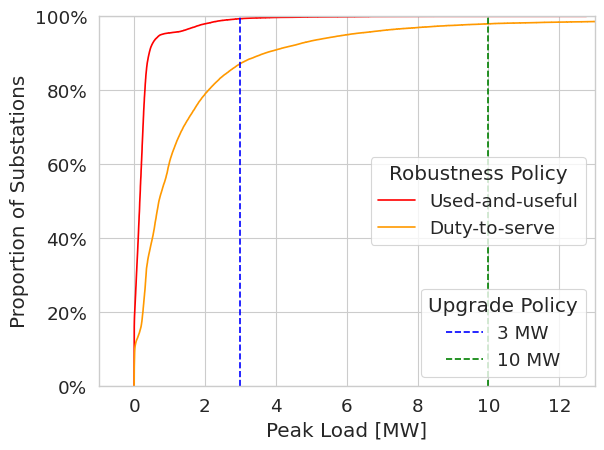

In [20]:
fig, ax = plt.subplots()
uur = ax.ecdf(x=plot_df.loc[plot_df["Robustness Policy"] == "Used-and-useful", "value"], color = UUR_COLOR, label="Used-and-useful")
dsr = ax.ecdf(x=plot_df.loc[plot_df["Robustness Policy"] == "Duty-to-serve", "value"], color = DSR_COLOR, label="Duty-to-serve")
v1 = ax.axvline(x=3, color="blue", linestyle="--", label="3 MW")
v2 = ax.axvline(x=10, color="green", linestyle="--", label="10 MW")
ax.set_xlim(left=-1, right=13)
ax.set_xlabel("Peak Load [MW]")
ax.set_ylabel("Proportion of Substations")
ax.yaxis.set_major_formatter(PercentFormatter(1))
leg_robust = ax.legend(handles = [uur, dsr], loc="center right", title="Robustness Policy")
ax.add_artist(leg_robust)
ax.legend(handles = [v1, v2], loc="lower right", title="Upgrade Policy");

catalog.save("robust_upgrade_combos", ax.figure)
ax.figure

### Figures 5 and 7: Maps of robust peak loads

Exports polygon and point GeoDataFrames of per-substation DSR and UUR peak loads, used in QGIS to produce **Figure 5** (continental U.S. choropleth of peak e-HDT charging loads by substation territory) and **Figure 7** (SF Bay Area inset at higher resolution).

In [21]:
robust_subs_polys = robust_subs.copy()
robust_subs_polys["geometry"] = robust_subs_polys.index.map(sub_polys_contin)
robust_subs_polys = gpd.GeoDataFrame(robust_subs_polys, geometry="geometry", crs=sub_polys_contin.crs)

In [22]:
catalog.save("vehicle_peak_load_by_substation_partition", {str(reader.dirs[0]): robust_subs_polys})

[06/11/26 09:15:07] INFO     Saving data to vehicle_peak_load_by_substation_partition          ]8;id=75497;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=602551;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (PartitionedDataset)...                                                               

In [23]:
robust_subs_pts = robust_subs.copy()
robust_subs_pts["geometry"] = robust_subs_pts.index.map(sub_pts_contin)
robust_subs_pts = gpd.GeoDataFrame(robust_subs_pts, geometry="geometry", crs=sub_pts_contin.crs)

In [24]:
catalog.save("vehicle_peak_load_by_substation_points_partition", {str(reader.dirs[0]): robust_subs_pts})

[06/11/26 09:15:37] INFO     Saving data to vehicle_peak_load_by_substation_points_partition   ]8;id=903654;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=211279;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (PartitionedDataset)...                                                               